Total labels loaded: 32036


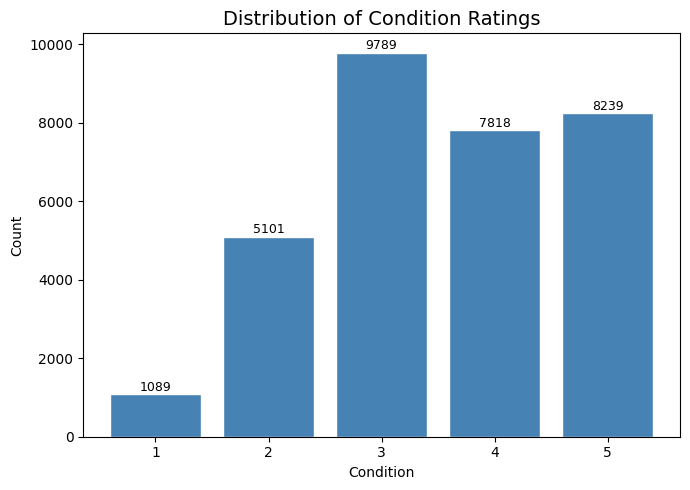

In [11]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter

data_dir = Path("../data")

condition_values = []

for json_file in data_dir.rglob("*.json"):
    with open(json_file) as f:
        label = json.load(f)
    if "condition" in label:
        condition_values.append(label["condition"])

print(f"Total labels loaded: {len(condition_values)}")

condition_counts = Counter(condition_values)
condition_bins = sorted(condition_counts.keys())

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(condition_bins, [condition_counts[k] for k in condition_bins], color="steelblue", edgecolor="white")
ax.set_title("Distribution of Condition Ratings", fontsize=14)
ax.set_xlabel("Condition")
ax.set_ylabel("Count")
ax.set_xticks(condition_bins)
for x, y in zip(condition_bins, [condition_counts[k] for k in condition_bins]):
    ax.text(x, y + 5, str(y), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


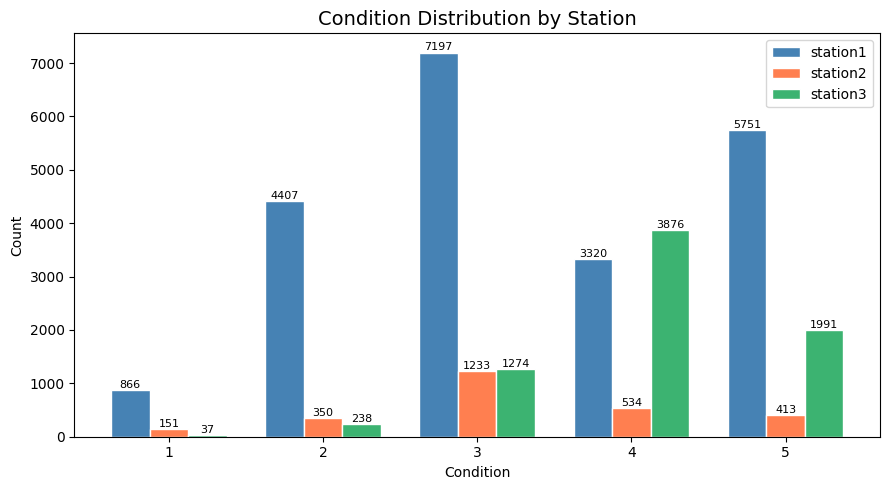

In [12]:
stations = ["station1", "station2", "station3"]
colors = {"station1": "steelblue", "station2": "coral", "station3": "mediumseagreen"}
rating_range = range(1, 6)

station_condition = {}
for station in stations:
    station_dir = Path("../data/clothing_v3") / station
    vals = []
    for json_file in station_dir.rglob("*.json"):
        with open(json_file) as f:
            label = json.load(f)
        if "condition" in label:
            vals.append(label["condition"])
    station_condition[station] = vals

import numpy as np

x = np.array(list(rating_range))
width = 0.25
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(9, 5))

for station, offset in zip(stations, offsets):
    counts = Counter(station_condition[station])
    heights = [counts.get(r, 0) for r in rating_range]
    bars = ax.bar(x + offset, heights, width=width, label=station,
                  color=colors[station], edgecolor="white")
    for bar, h in zip(bars, heights):
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 2, str(h),
                    ha="center", va="bottom", fontsize=8)

ax.set_title("Condition Distribution by Station", fontsize=14)
ax.set_xlabel("Condition")
ax.set_ylabel("Count")
ax.set_xticks(list(x))
ax.set_xticklabels(list(rating_range))
ax.legend()
plt.tight_layout()
plt.show()


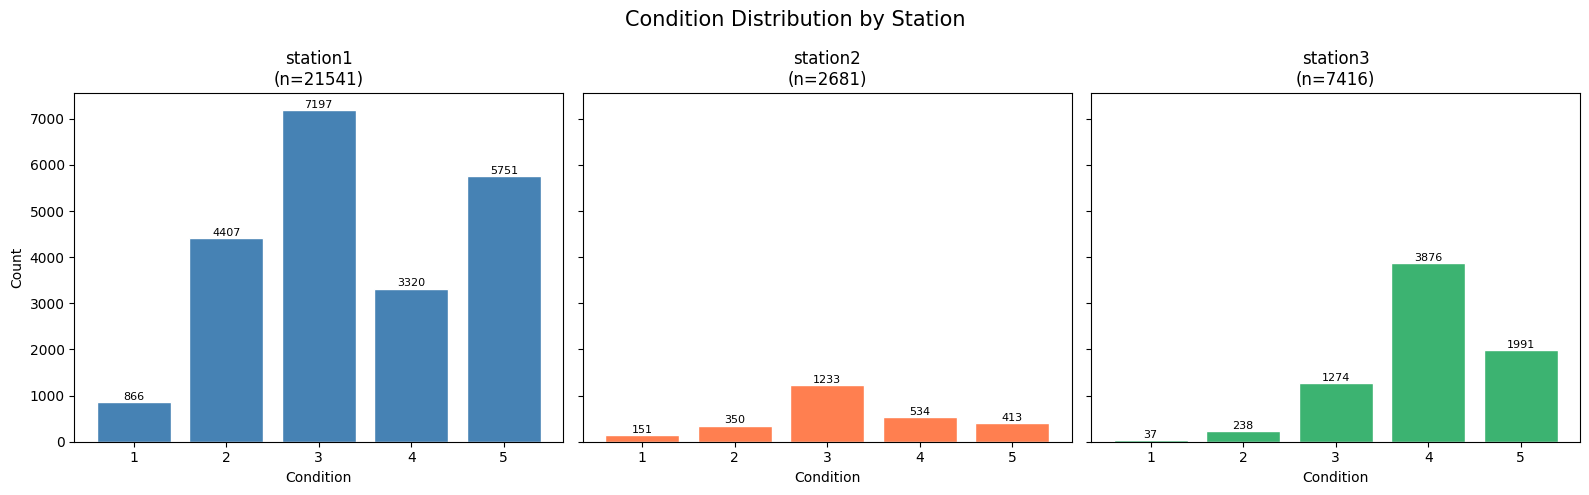

Station           n    mean    median
--------------------------------------
station1      21541    3.40         3
station2       2681    3.26         3
station3       7416    4.02         4


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for col, station in enumerate(stations):
    counts = Counter(station_condition[station])
    n = len(station_condition[station])
    heights = [counts.get(r, 0) for r in rating_range]

    ax = axes[col]
    ax.bar(list(rating_range), heights, color=colors[station], edgecolor="white")
    ax.set_title(f"{station}\n(n={n})", fontsize=12)
    ax.set_xlabel("Condition")
    ax.set_xticks(list(rating_range))
    if col == 0:
        ax.set_ylabel("Count")
    for x, y in zip(rating_range, heights):
        if y > 0:
            ax.text(x, y + 2, str(y), ha="center", va="bottom", fontsize=8)

fig.suptitle("Condition Distribution by Station", fontsize=15)
plt.tight_layout()
plt.show()

print(f"{'Station':<12} {'n':>6}  {'mean':>6}  {'median':>8}")
print("-" * 38)
for station in stations:
    vals = station_condition[station]
    mean = sum(vals) / len(vals)
    median = sorted(vals)[len(vals) // 2]
    print(f"{station:<12} {len(vals):>6}  {mean:>6.2f}  {median:>8}")


Index built: 32036 labeled items
Condition 5: 8239 items — showing 5


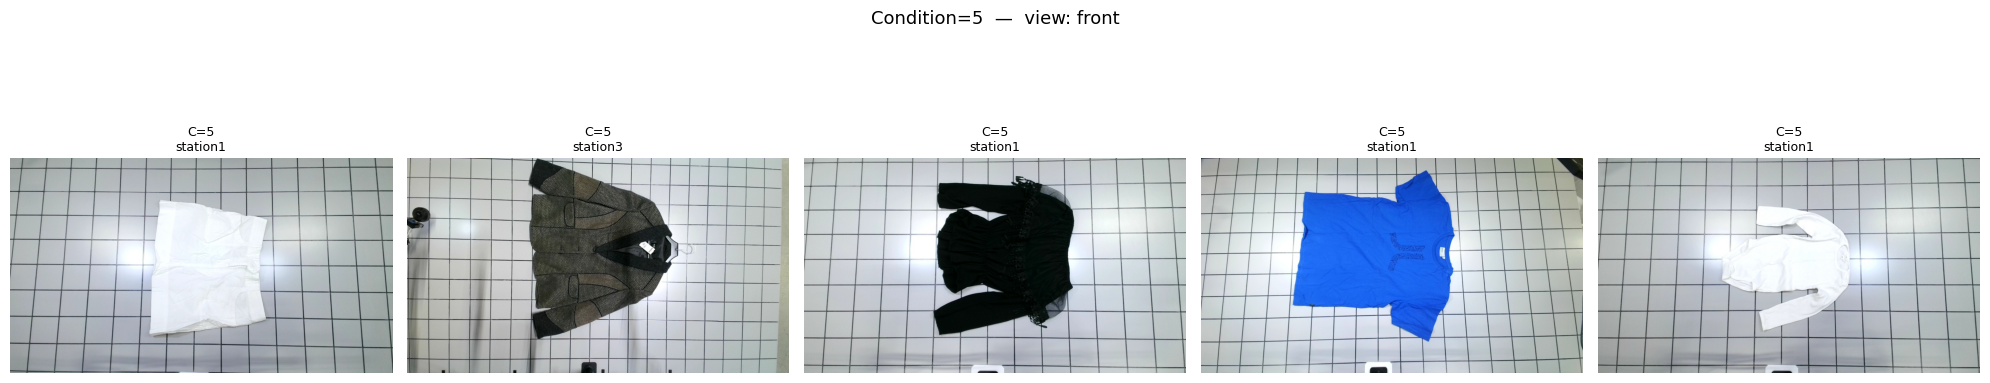

Condition 1: 1089 items — showing 5


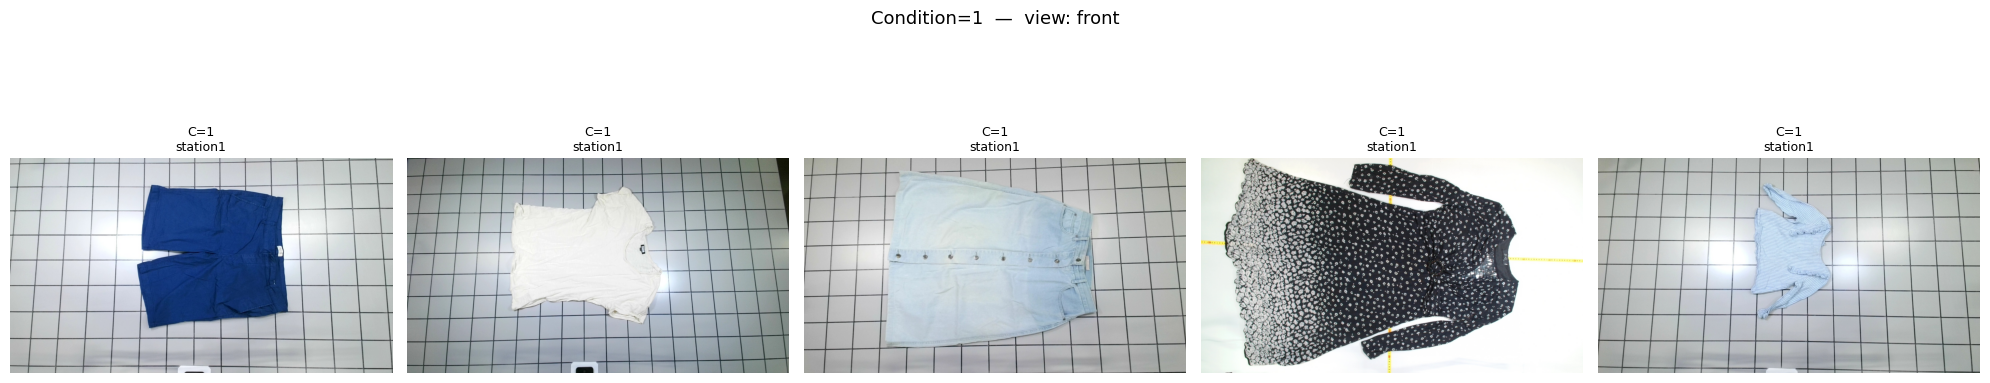

In [14]:
import random
from PIL import Image

# ── Build index of all labels ─────────────────────────────────────────────────
label_index = []  # list of dicts: {condition, folder, timestamp}

for json_file in Path("../data").rglob("labels_*.json"):
    with open(json_file) as f:
        label = json.load(f)
    cond = label.get("condition")
    if cond is not None:
        timestamp = json_file.stem.replace("labels_", "")
        label_index.append({
            "condition": cond,
            "folder":    json_file.parent,
            "timestamp": timestamp,
        })

print(f"Index built: {len(label_index)} labeled items")

# ── Sample viewer ─────────────────────────────────────────────────────────────
def show_cluster(condition: int, n: int = 5, view: str = "front"):
    """
    Display `n` random images from items whose condition == condition.

    Parameters
    ----------
    condition : int   1–5
    n         : int   number of samples to show (default 5)
    view      : str   one of 'front', 'back', 'brand' (default 'front')
    """
    cluster = [e for e in label_index if e["condition"] == condition]

    if not cluster:
        print(f"No items found for condition={condition}")
        return

    sample = random.sample(cluster, min(n, len(cluster)))
    print(f"Condition {condition}: {len(cluster)} items — showing {len(sample)}")

    fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 5))
    if len(sample) == 1:
        axes = [axes]

    for ax, entry in zip(axes, sample):
        img_path = entry["folder"] / f"{view}_{entry['timestamp']}.jpg"
        if img_path.exists():
            ax.imshow(Image.open(img_path))
        else:
            ax.text(0.5, 0.5, "image\nnot found", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"C={entry['condition']}\n{entry['folder'].parent.name}", fontsize=9)
        ax.axis("off")

    fig.suptitle(f"Condition={condition}  —  view: {view}", fontsize=13)
    plt.tight_layout()
    plt.show()

# ── Change these to explore any condition ────────────────────────────────────
show_cluster(condition=5)
show_cluster(condition=1)


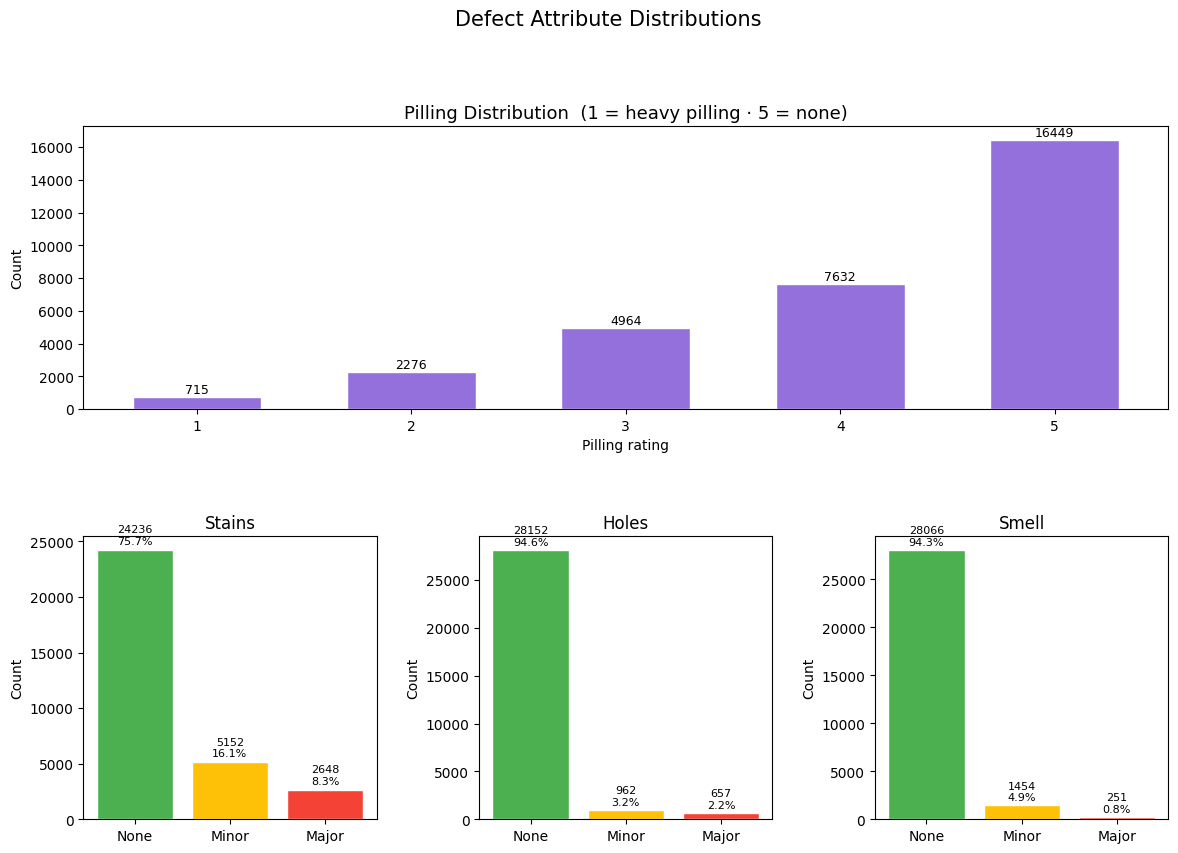

Pilling  — mean: 4.15  (n=32036)

Stains   —  7800 defective / 32036 total  (24.3%)
Holes    —  1619 defective / 29771 total  (5.4%)
Smell    —  1705 defective / 29771 total  (5.7%)


In [15]:
from collections import Counter
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np

# ── Normalise categorical fields ──────────────────────────────────────────────
def normalise_cat(value):
    """Map dirty stains/holes/smell values to None / Minor / Major."""
    v = str(value).strip().lower()
    if v in ("none", "no"):
        return "None"
    if v in ("minor", "yes"):   # 'Yes' = stain present but unlabelled severity → Minor
        return "Minor"
    if v == "major":
        return "Major"
    return "Other"

# ── Collect counts ─────────────────────────────────────────────────────────────
pilling_counts  = Counter()
stains_counts   = Counter()
holes_counts    = Counter()
smell_counts    = Counter()

for json_file in Path("../data").rglob("labels_*.json"):
    with open(json_file) as f:
        label = json.load(f)
    if "pilling" in label:
        pilling_counts[label["pilling"]] += 1
    for field, counter in [("stains", stains_counts), ("holes", holes_counts), ("smell", smell_counts)]:
        if field in label:
            counter[normalise_cat(label[field])] += 1

# ── Layout: pilling bar on top, three category bars on bottom ─────────────────
fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

ax_pill = fig.add_subplot(gs[0, :])   # full-width top row
ax_stain = fig.add_subplot(gs[1, 0])
ax_holes = fig.add_subplot(gs[1, 1])
ax_smell  = fig.add_subplot(gs[1, 2])

# ── Pilling (1–5) ─────────────────────────────────────────────────────────────
pill_bins   = list(range(1, 6))
pill_heights = [pilling_counts.get(b, 0) for b in pill_bins]
bars = ax_pill.bar(pill_bins, pill_heights, color="mediumpurple", edgecolor="white", width=0.6)
ax_pill.set_title("Pilling Distribution  (1 = heavy pilling · 5 = none)", fontsize=13)
ax_pill.set_xlabel("Pilling rating")
ax_pill.set_ylabel("Count")
ax_pill.set_xticks(pill_bins)
for bar, h in zip(bars, pill_heights):
    ax_pill.text(bar.get_x() + bar.get_width() / 2, h + 40, str(h),
                 ha="center", va="bottom", fontsize=9)

# ── Helper for None / Minor / Major bars ─────────────────────────────────────
cat_order  = ["None", "Minor", "Major"]
cat_colors = ["#4CAF50", "#FFC107", "#F44336"]

def draw_cat(ax, counter, title):
    heights = [counter.get(c, 0) for c in cat_order]
    total   = sum(heights)
    bars = ax.bar(cat_order, heights, color=cat_colors, edgecolor="white")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Count")
    for bar, h in zip(bars, heights):
        pct = f"{h / total * 100:.1f}%" if total else ""
        ax.text(bar.get_x() + bar.get_width() / 2, h + total * 0.01,
                f"{h}\n{pct}", ha="center", va="bottom", fontsize=8)

draw_cat(ax_stain, stains_counts, "Stains")
draw_cat(ax_holes, holes_counts,  "Holes")
draw_cat(ax_smell, smell_counts,  "Smell")

fig.suptitle("Defect Attribute Distributions", fontsize=15, y=1.01)
plt.show()

# ── Quick summary table ───────────────────────────────────────────────────────
total = sum(pilling_counts.values())
pill_mean = sum(k * v for k, v in pilling_counts.items()) / total
print(f"Pilling  — mean: {pill_mean:.2f}  (n={total})\n")
for name, counter in [("Stains", stains_counts), ("Holes", holes_counts), ("Smell", smell_counts)]:
    n = sum(counter.values())
    defective = n - counter.get("None", 0)
    print(f"{name:<8} — {defective:>5} defective / {n} total  ({defective/n*100:.1f}%)")
